<a href="https://colab.research.google.com/github/ag22042008/data-Science-notebooks/blob/main/image_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow import keras

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification model

In [36]:
df=pd.read_csv('/content/train42.csv.zip')


In [37]:
df

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [38]:
df.head(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [39]:
df.columns

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=785)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [41]:
df.isnull().sum()

,0
label,0
pixel0,0
pixel1,0
pixel2,0
pixel3,0
...,...
pixel779,0
pixel780,0
pixel781,0
pixel782,0


In [42]:
# Fill all NaN values with 0
df.fillna(0, inplace=True)

In [43]:
df.isnull().sum()

,0
label,0
pixel0,0
pixel1,0
pixel2,0
pixel3,0
...,...
pixel779,0
pixel780,0
pixel781,0
pixel782,0


In [44]:
X=df.drop('label',axis=1)
y=df['label']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
X_train=X_train.astype('float32')/255.0
X_test=X_test.astype('float32')/255.0

)

👉 -1 = “fill this dimension automatically so total elements stay same” means -1 will automatically figure out total no of images


In [47]:
X_train_img=X_train.values.reshape(-1,28,28)
X_test_img=X_test.values.reshape(-1,28,28)

Total number of classes = 10 (digits 0–9)

In [48]:
y_train_cat=to_categorical(y_train,10)

In [49]:
y_test_cat=to_categorical(y_test,10)

In [50]:
perceptron = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(10, activation='softmax')
])

In [51]:
perceptron.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [52]:
history_per=perceptron.fit(X_train_img, y_train_cat, epochs=10,batch_size=32,validation_split=0.2,verbose=1)

Epoch 1/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8409 - loss: 0.6230 - val_accuracy: 0.8973 - val_loss: 0.3887
Epoch 2/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9036 - loss: 0.3432 - val_accuracy: 0.9107 - val_loss: 0.3290
Epoch 3/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9143 - loss: 0.3045 - val_accuracy: 0.9162 - val_loss: 0.3073
Epoch 4/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9195 - loss: 0.2863 - val_accuracy: 0.9204 - val_loss: 0.2991
Epoch 5/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9225 - loss: 0.2738 - val_accuracy: 0.9207 - val_loss: 0.2902
Epoch 6/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9246 - loss: 0.2653 - val_accuracy: 0.9219 - val_loss: 0.2883
Epoch 7/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9273 - loss: 0.2587 - val_accuracy: 0.9237 - val_loss: 0.2809
Epoch 8/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9278 - loss: 0.2532 - val_accuracy: 0.

In [53]:
acc_per=perceptron.evaluate(X_test_img,y_test_cat)[1]

263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9194 - loss: 0.2851


In [54]:
acc_per

0.9194047451019287

[0] → loss  
[1] → accuracy ✅
🎯 So:
acc_per = perceptron.evaluate(...)[1]

👉 You are extracting accuracy only

In [55]:
from tensorflow.keras.callbacks import EarlyStopping

early = EarlyStopping(patience=2, restore_best_weights=True)

In [56]:
#ANN
ann=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
     Dropout(0.3),
    Dense(60,activation='relu'),
    Dense(10,activation='softmax')

])

In [57]:
ann.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [58]:
history=ann.fit(X_train_img,y_train_cat,epochs=10,batch_size=32,validation_data=[X_test_img,y_test_cat],callbacks=[early],verbose=1)

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8819 - loss: 0.3846 - val_accuracy: 0.9479 - val_loss: 0.1771
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9440 - loss: 0.1879 - val_accuracy: 0.9588 - val_loss: 0.1362
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9551 - loss: 0.1450 - val_accuracy: 0.9618 - val_loss: 0.1211
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9608 - loss: 0.1244 - val_accuracy: 0.9667 - val_loss: 0.1133
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9662 - loss: 0.1068 - val_accuracy: 0.9704 - val_loss: 0.0979
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9690 - loss: 0.0942 - val_accuracy: 0.9689 - val_loss: 0.0988
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9717 - loss: 0.0851 - val_accuracy: 0.9702 - val_loss: 0.1023


In [59]:
acc_ann=ann.evaluate(X_test_img,y_test_cat)[1]

263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9704 - loss: 0.0979


-1 for the figuring the size yourself 1 the gray scale colur channel 3-rgb colour channel


In [60]:
X_train_cnn=X_train.values.reshape(-1,28,28,1)
X_test_cnn=X_test.values.reshape(-1,28,28,1)

In [61]:
cnn=Sequential()
cnn.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
cnn.add(MaxPooling2D(2,2))
cnn.add(Conv2D(64,(3,3),activation='relu'))
cnn.add(MaxPooling2D(2,2))
cnn.add(Flatten())
cnn.add(Dense(128,activation='relu'))
Dropout(0.5)
cnn.add(Dense(10,activation='softmax'))



In [62]:
cnn.compile(optimizer='Adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [63]:
history_cnn=cnn.fit(X_train_cnn,y_train_cat,epochs=5,batch_size=32,validation_data=(X_test_cnn,y_test_cat),verbose=1)

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.9485 - loss: 0.1755 - val_accuracy: 0.9776 - val_loss: 0.0684
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - accuracy: 0.9828 - loss: 0.0542 - val_accuracy: 0.9835 - val_loss: 0.0519
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.9882 - loss: 0.0364 - val_accuracy: 0.9846 - val_loss: 0.0481
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.9909 - loss: 0.0276 - val_accuracy: 0.9881 - val_loss: 0.0343
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - accuracy: 0.9941 - loss: 0.0193 - val_accuracy: 0.9886 - val_loss: 0.0404
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - accuracy: 0.9940 - loss: 0.0175 - val_accuracy: 0.9885 - val_loss: 0.0402
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.9965 - loss: 0.0112 - val_accuracy: 0.9874 - val_loss: 0.0427
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.9964 -

In [64]:
acc_cnn=cnn.evaluate(X_test_cnn,y_test_cat)[1]
acc_cnn

263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9883 - loss: 0.0438


0.9883333444595337

def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

In [65]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'],label="Test")
    plt.title(f"{title} Accuracy")
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'],label="Test")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()


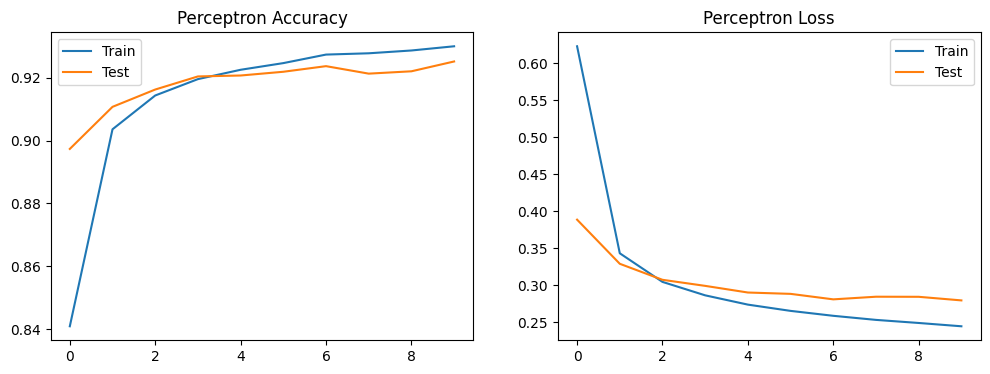

In [66]:
plot_training(history_per,'Perceptron')

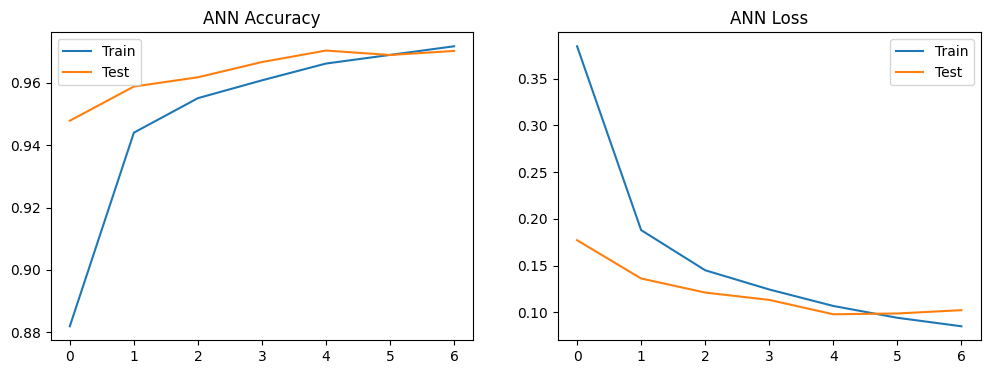

In [67]:
plot_training(history,'ANN')

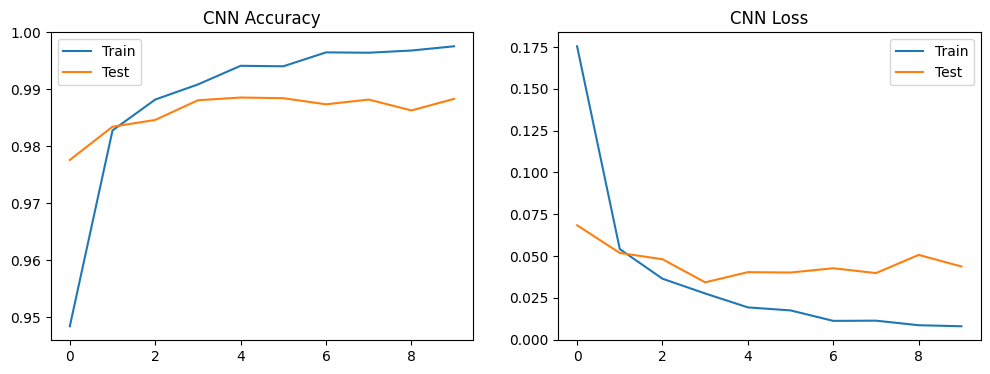

In [68]:
plot_training(history_cnn,'CNN')

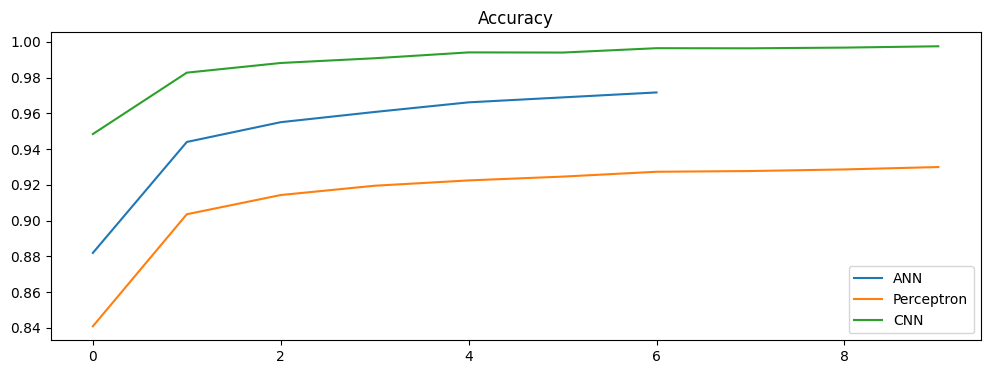

In [70]:
plt.figure(figsize=(12,4))
plt.plot(history.history['accuracy'],label='ANN')
plt.plot(history_per.history['accuracy'],label='Perceptron')
plt.plot(history_cnn.history['accuracy'],label='CNN')
plt.title('Accuracy')
plt.legend()
plt.show()

In [90]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    # Step 1: Pick n random images
    idxs = np.random.choice(len(X), n, replace=False)

    fig, axes = plt.subplots(2, n, figsize=(15, 7))

    for i, idx in enumerate(idxs):
        # Step 2: Show the image in the top row
        image = X[idx].reshape(28, 28)
        axes[0, i].imshow(image, cmap="gray")
        axes[0, i].axis("off")
        axes[0, i].set_title(f"True: {y_true.iloc[idx]}") # Changed y_true[idx] to y_true.iloc[idx]

        # Step 3: Get each model's prediction
        pred_text = ""
        for model, name in zip(models, model_names):
            if name == "CNN":
                input_data = X_cnn[idx].reshape(1, 28, 28, 1)
            else:
                input_data = X[idx].reshape(1, 28, 28)

            prediction = np.argmax(model.predict(input_data))
            pred_text += f"{name}: {prediction}\n"

        # Step 4: Show predictions in the bottom row
        axes[1, i].axis("off")
        axes[1, i].set_title(pred_text.strip())

    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


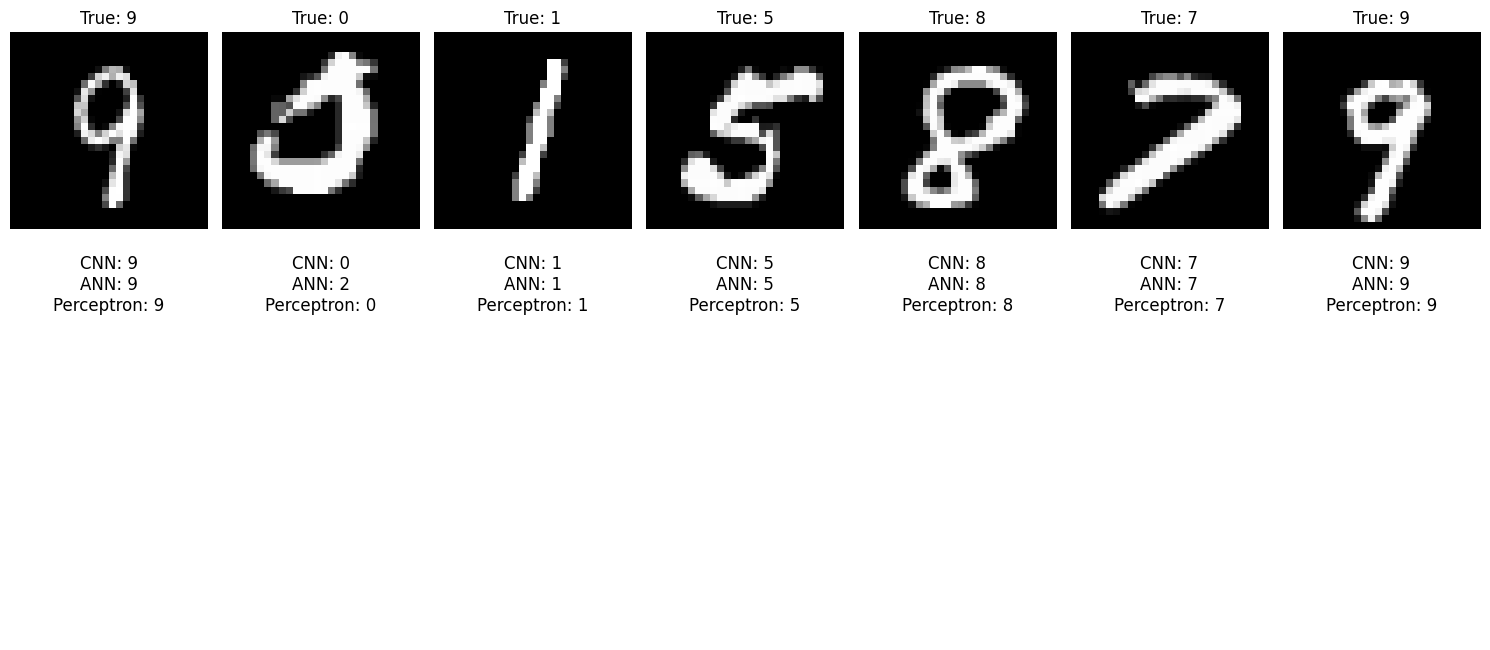

In [91]:

show_side_by_side([cnn, ann, perceptron], ["CNN", "ANN", "Perceptron"], X_test_img, X_test_cnn, y_test, 7)